In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

import raytrace

rng = np.random.default_rng()

colors = ['red', 'orangered','yellowgreen', 'royalblue', 'blueviolet']
cm_kpc = u.cm.to(u.kpc)
cm_kpc

with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo_ids = list(f.keys())
halo_ids = [id[5:] for id in halo_ids[3:]]

with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    group_sfr = list()
    sub0_relax_dist = list()
    sub0_relax_mass = list()
    dm_near_mean = list()
    dm_near_std = list()
    dm_far_mean = list()
    dm_far_std = list()
    dm_far_mean200 = list()
    dm_far_mean500 = list()
    halo_mass = list()
    halo_m200 = list()
    halo_m500 = list()
    halo_r200 = list()
    halo_r500 = list()
    halo_fe200 = list()
    halo_fe500 = list()
    halo_fgas200 = list()
    halo_fgas500 = list()
    com_impact_dm_far = list()

    for halo_id in halo_ids:
        halo = f['halo_' + halo_id]    
        if 'trace' not in halo:
            continue
        if 'Group_Fgas_Crit500' not in halo:
            continue

        halo_mass.append(np.sum(halo['GroupMassType'][:]))
        halo_r500.append(halo['Group_R_Crit500'][()])
        halo_r200.append(halo['Group_R_Crit200'][()])
        halo_fgas500.append(halo['Group_Fgas_Crit500'][()])
        halo_fgas200.append(halo['Group_Fgas_Crit200'][()])
        halo_fe500.append(halo['Group_Fe_Crit500'][()])
        halo_fe200.append(halo['Group_Fe_Crit200'][()])
        halo_m500.append(halo['Group_M_Crit500'][()])
        halo_m200.append(halo['Group_M_Crit200'][()])
        subs = halo['subhalos']
        com = halo['GroupCM'][:]
    
        # central subhalo relaxation
        # print(subs.keys())
        # break
        sub0_cm = np.array([ subs['cm_x'][0], subs['cm_y'][0], subs['cm_z'][0] ]).T
        sub0_relax_dist.append(np.linalg.norm(sub0_cm) / subs['halfmassrad'][0])
        sub0_relax_mass.append(subs['mass'][0] / np.sum(halo['GroupMassType'][:]))
        group_sfr.append(halo['GroupSFR'][()])

        trace = halo['trace']
        # print('\n'.join(list(subs.keys())))
        dot = np.dot(trace['star_pos'], trace['direction'], axis=1)
        com_impact = np.linalg.norm(np.cross(trace['star_pos'], trace['direction'], axis=1), axis=-1)
        dm_near = trace['dm_voronoi'][:, -1, 1] * (cm_kpc**3) * 1000
        dm_far = (trace['dm_voronoi'][:, -1, -1] * (cm_kpc**3) * 1000) - dm_near

        dm_near_mean.append(np.mean(dm_near))
        dm_near_std.append(np.std(dm_near))

        dm_far_mean200.append(np.mean(dm_far[com_impact < halo_r200[-1]]))
        dm_far_mean500.append(np.mean(dm_far[com_impact < halo_r500[-1]]))
        com_impact_dm_far.append((np.sum(dm_far*com_impact)/np.sum(dm_far)))

        dm_far_mean.append(np.mean(dm_far))
        dm_far_std.append(np.std(dm_far))
    # print(impact.shape, dm.shape)
group_sfr = np.array(group_sfr)
sub0_relax_dist = np.array(sub0_relax_dist)
sub0_relax_mass = np.array(sub0_relax_mass)
dm_near_mean = np.array(dm_near_mean)
dm_near_std = np.array(dm_near_std)
dm_far_mean = np.array(dm_far_mean)
dm_far_std = np.array(dm_far_std)
dm_far_mean200 = np.array(dm_far_mean200)
dm_far_mean500 = np.array(dm_far_mean500)
halo_mass = np.array(halo_mass)
halo_m200 = np.array(halo_m200)
halo_m500 = np.array(halo_m500)
halo_r200 = np.array(halo_r200)
halo_r500 = np.array(halo_r500)
halo_fgas200 = np.array(halo_fgas200)
halo_fgas500 = np.array(halo_fgas500)
halo_fe200 = np.array(halo_fe200)
halo_fe500 = np.array(halo_fe500)
com_impact_dm_far = np.array(com_impact_dm_far)

# Fgas

(array([ 3., 12., 13.,  9.,  8.,  4.,  1.,  1.,  0.,  1.]),
 array([1.44832439, 1.47632995, 1.50433551, 1.53234107, 1.56034663,
        1.58835219, 1.61635775, 1.64436331, 1.67236887, 1.70037443,
        1.72837999]),
 <BarContainer object of 10 artists>)

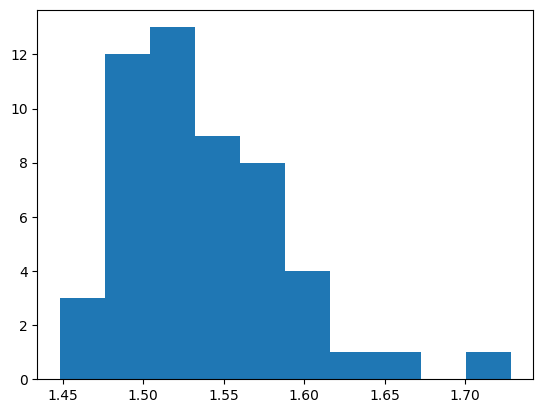

In [12]:
plt.hist(halo_r200/halo_r500)

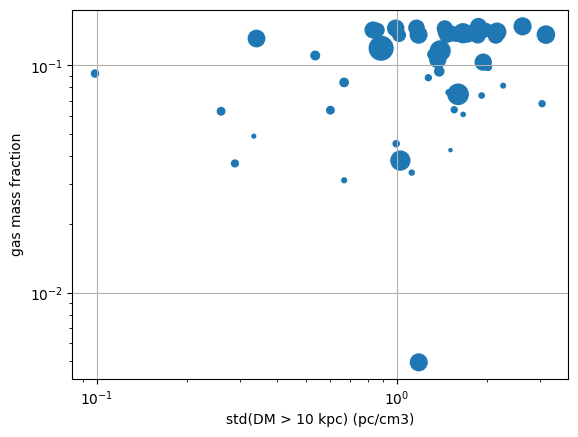

In [2]:
plt.scatter(np.array(dm_far_std)/dm_far_mean, halo_fgas500, s=(np.array(halo_mass))*1e-3)
plt.loglog()
# plt.xlim(1e2,1e4)
plt.grid()
# plt.legend()
plt.xlabel('std(DM > 10 kpc) (pc/cm3)')
plt.ylabel('gas mass fraction')
plt.savefig('vis/halo_trends/fgas_dmstd.png')
plt.show()

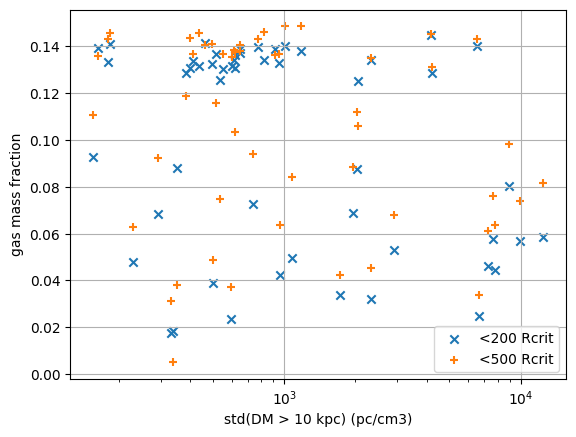

In [113]:
plt.scatter(np.array(dm_far_std), halo_fgas200, label='<200 Rcrit', marker='x')
plt.scatter(np.array(dm_far_std), halo_fgas500, label='<500 Rcrit', marker='+')
plt.semilogx()
# plt.xlim(1e2,1e4)
plt.grid()
plt.legend()
plt.xlabel('std(DM > 10 kpc) (pc/cm3)')
plt.ylabel('gas mass fraction')
plt.savefig('vis/halo_trends/fgas_dmstd.png')
plt.show()

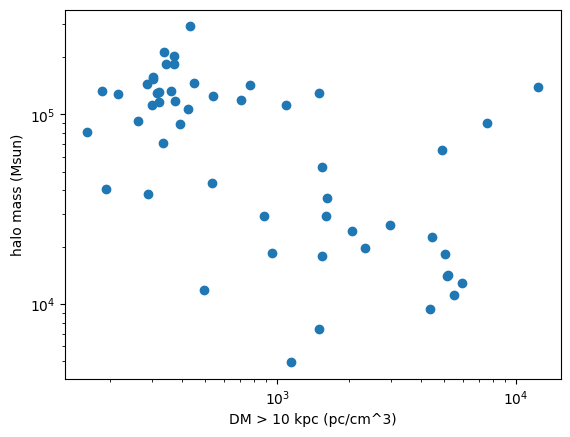

In [2]:
plt.scatter(dm_far_mean, halo_mass)
plt.loglog()
plt.ylabel('halo mass (Msun)')
plt.xlabel('DM > 10 kpc (pc/cm^3)')
plt.show()

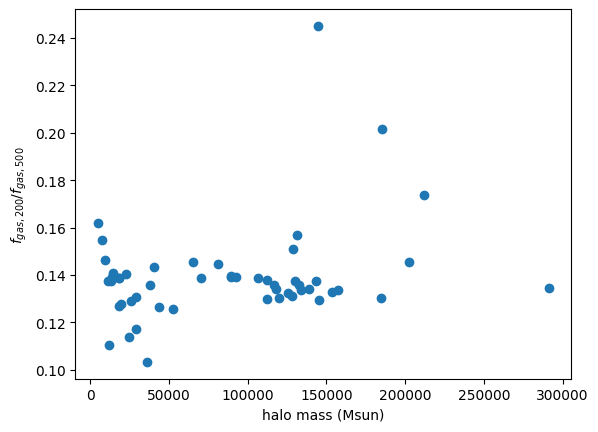

In [115]:
plt.scatter(halo_mass, (np.log10(halo_fgas200/halo_fgas500)+0.7)/np.log10(halo_mass))
plt.xlabel('halo mass (Msun)')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.show()

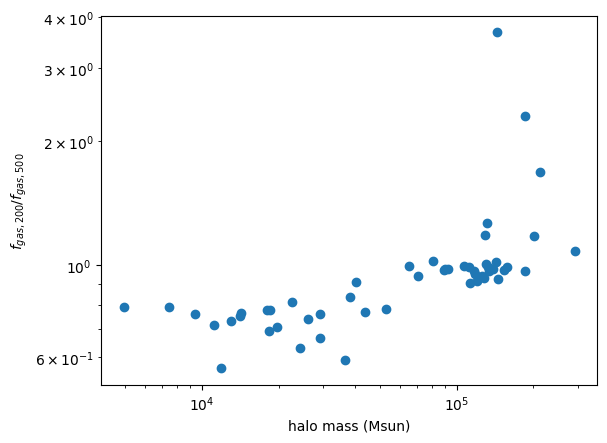

In [116]:
plt.scatter(halo_mass, halo_fgas200/halo_fgas500)
plt.loglog()
plt.xlabel('halo mass (Msun)')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.show()

In [4]:
len(dm_far_mean)

52

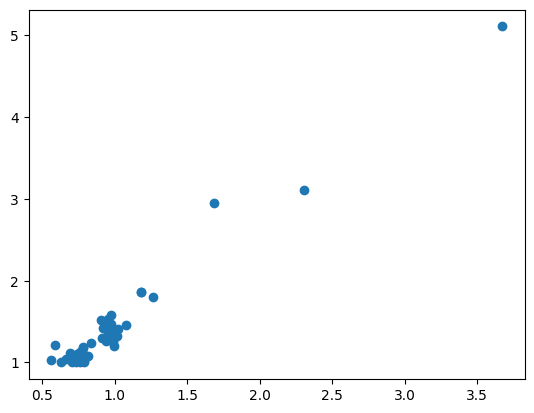

In [9]:
plt.scatter(halo_fgas200/halo_fgas500, halo_m200*halo_fgas200/(halo_m500*halo_fgas500))

/tmp/ipykernel_9524/2112942632.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


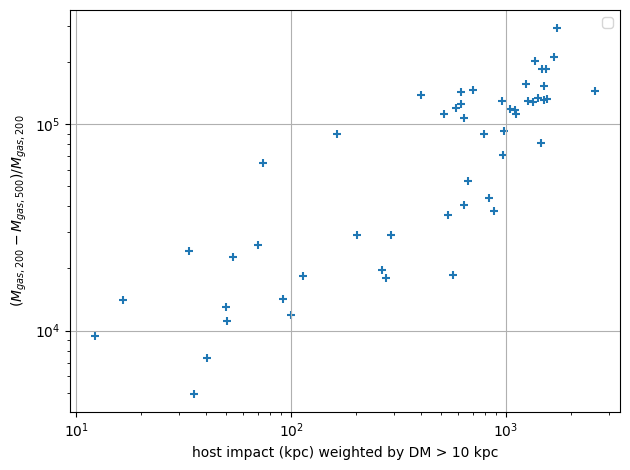

In [50]:
plt.scatter(com_impact_dm_far, halo_mass, marker='+')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('host impact (kpc) weighted by DM > 10 kpc')
plt.ylabel('$(M_{gas,200} - M_{gas,500})/M_{gas,200}$')
plt.savefig('vis/halo_trends/mgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

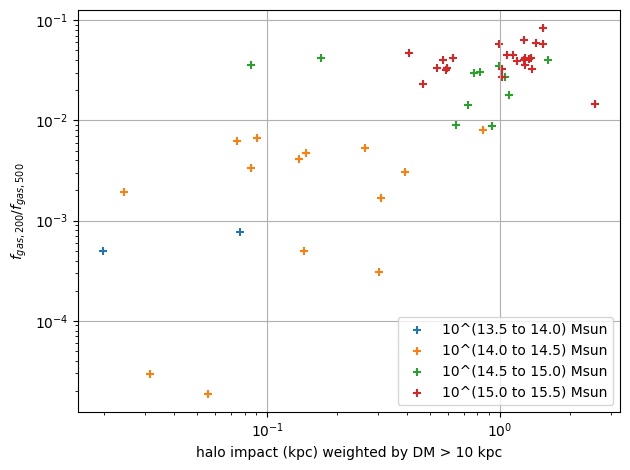

In [81]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter((com_impact_dm_far/halo_r500)[select], ((halo_fgas200*halo_m200-halo_fgas500*halo_m500)/halo_m200)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('halo impact (kpc) weighted by DM > 10 kpc')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

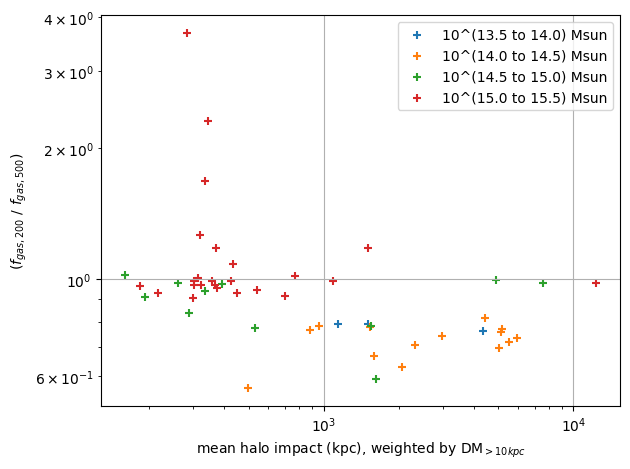

In [98]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas200/halo_fgas500)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('mean halo impact (kpc), weighted by DM$_{ > 10 kpc}$')
plt.ylabel('$(f_{gas,200}~/~f_{gas,500})$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

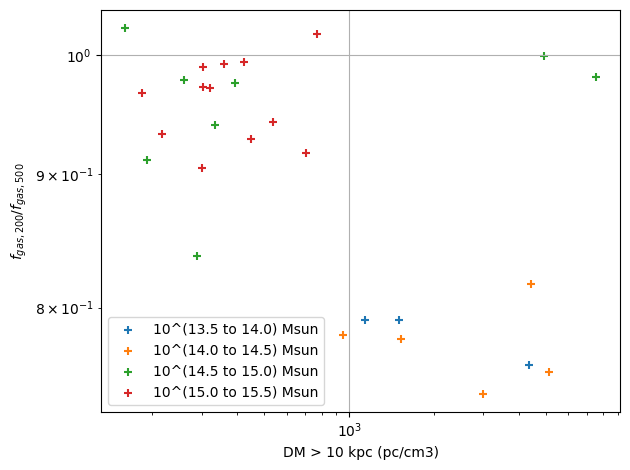

In [5]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1]) & (sub0_relax_mass > 0.85)
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas200/halo_fgas500)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,200}/f_{gas,500}$')
plt.savefig('vis/halo_trends/fgasdiff_dmfar.png')
plt.tight_layout()

plt.show()

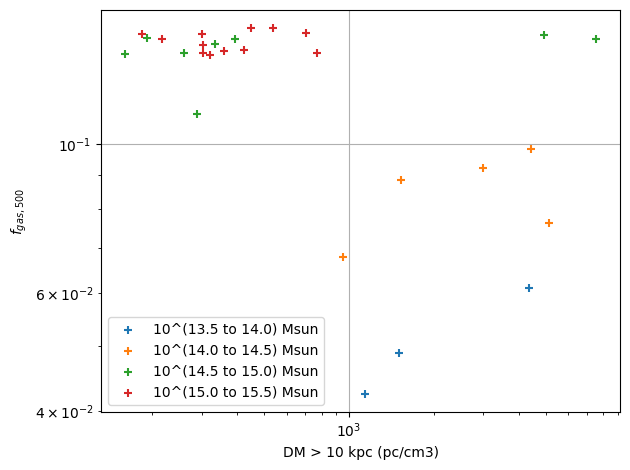

In [6]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1]) & (sub0_relax_mass > 0.85)
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas500)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,500}$')
plt.savefig('vis/halo_trends/fgas500_dmfar.png')
plt.tight_layout()
plt.show()

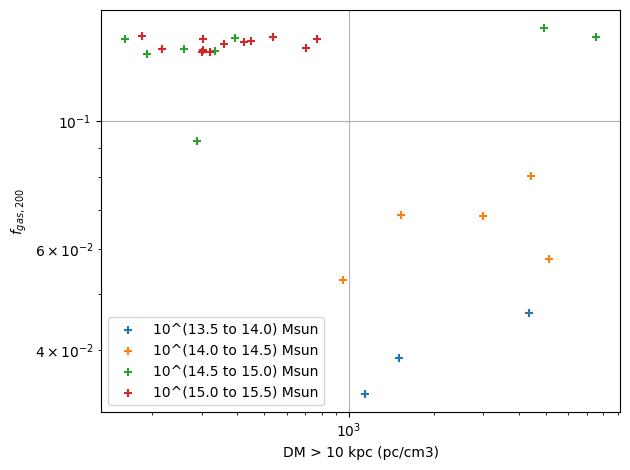

In [7]:
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1]) & (sub0_relax_mass > 0.85)
    if np.sum(select) < 1: continue
    plt.scatter(dm_far_mean[select], (halo_fgas200)[select], marker='+', label=f'10^({10+mrange[i]} to {10+mrange[i+1]}) Msun')
plt.loglog()
plt.legend()
# plt.xlim(1e2,1e4)
plt.grid()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('$f_{gas,200}$')
plt.savefig('vis/halo_trends/fgas200_dmfar.png')
plt.tight_layout()
plt.show()

/tmp/ipykernel_37129/838585087.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


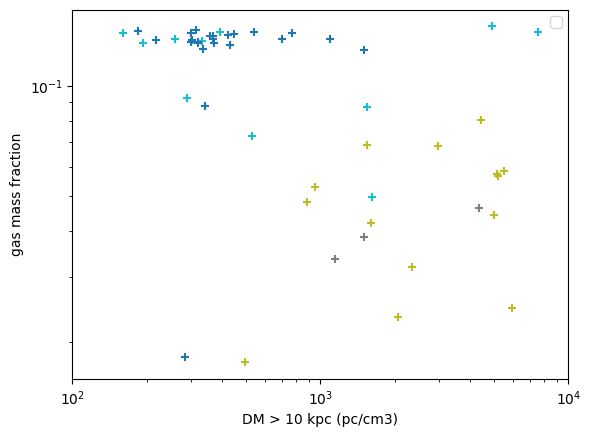

In [141]:
# plt.scatter(np.array(dm_far_mean), halo_fgas200, label='<200 Rcrit', s=(np.array(halo_mass))*1e-3)
# plt.scatter(np.array(dm_far_mean), halo_fgas500, label='<500 Rcrit', s=(np.array(halo_mass))*1e-3)
mrange = np.arange(0., 20., 0.5)
for i in range(len(mrange)-1):
    select = (10.**mrange[i] < halo_mass) & (halo_mass < 10.**mrange[i+1])
    plt.scatter(dm_far_mean[select], halo_fgas200[select], marker='+')

plt.loglog()
plt.xlim(1e2,1e4)
plt.legend()
plt.xlabel('DM > 10 kpc (pc/cm3)')
plt.ylabel('gas mass fraction')
plt.savefig('vis/halo_trends/fgas_dmfar.png')
plt.show()

# Other

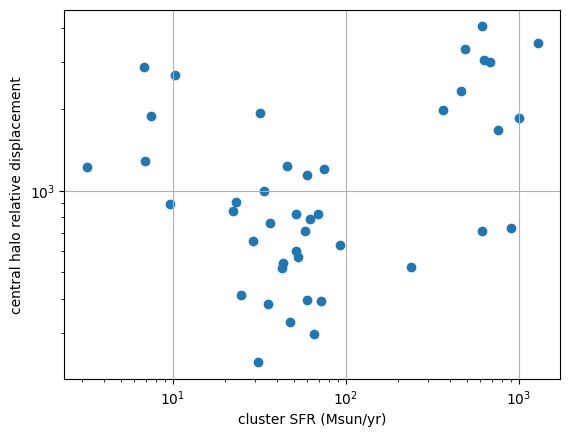

In [36]:
plt.scatter(group_sfr, sub0_relax_dist)
plt.loglog()
plt.xlabel('cluster SFR (Msun/yr)')
plt.ylabel('central halo relative displacement')
plt.grid()

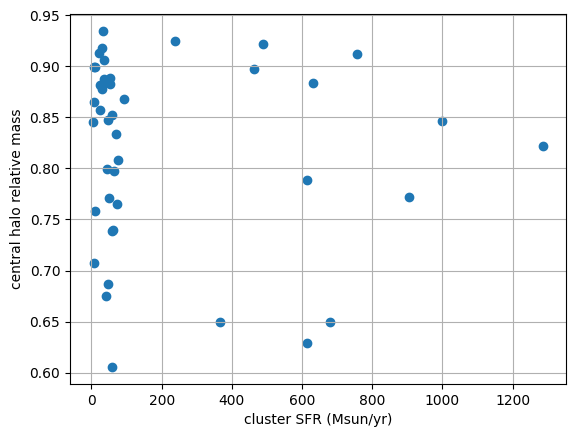

In [37]:
plt.scatter(group_sfr, sub0_relax_mass)
plt.xlabel('cluster SFR (Msun/yr)')
plt.ylabel('central halo relative mass')
plt.grid()

Text(0, 0.5, 'DM < 10 kpc')

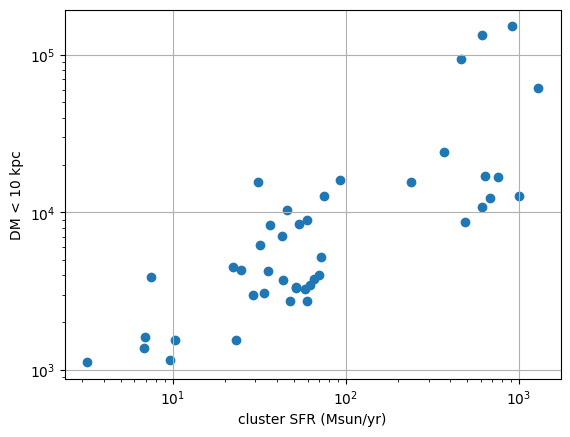

In [38]:
plt.scatter(group_sfr, np.array(dm_near_mean))
plt.xlabel('cluster SFR (Msun/yr)')
plt.loglog()
plt.grid()
plt.ylabel('DM < 10 kpc')

Text(0, 0.5, 'DM > 10 kpc')

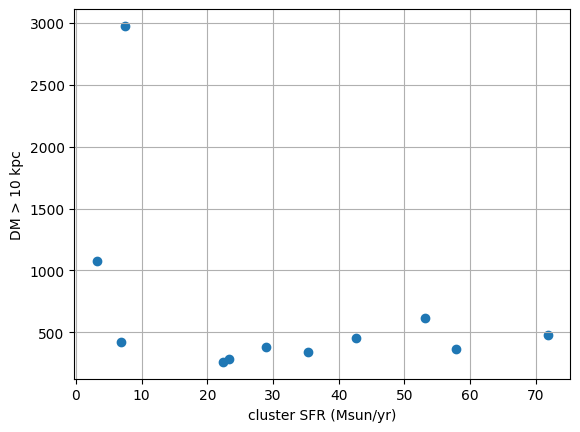

In [9]:
plt.scatter(group_sfr, np.array(dm_far_mean))
plt.xlabel('cluster SFR (Msun/yr)')
plt.grid()
plt.ylabel('DM > 10 kpc')

[]

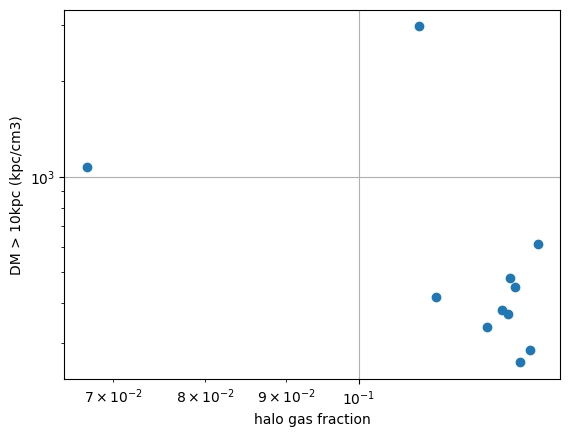

In [20]:
plt.scatter(halo_fgas, np.array(dm_far_mean) * (cm_kpc**3) * 1000)
plt.ylabel('DM > 10kpc (kpc/cm3)')
plt.grid()
plt.xlabel('halo gas fraction')
plt.loglog()

In [37]:
print(group_sfr)
print(halo_ids)

[np.float64(71.83643341064453), np.float64(23.260801315307617), np.float64(22.33913230895996), np.float64(7.512110233306885)]
['252455', '4152102', '4356618', '5160064']


Text(0, 0.5, 'DM < 10 kpc (pc/cm^3)')

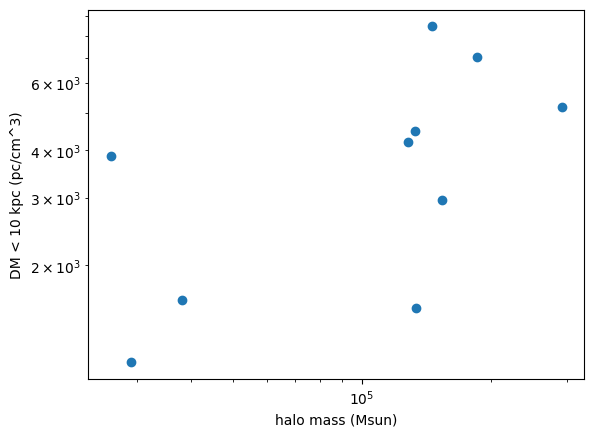

In [34]:
plt.scatter(halo_mass, np.array(dm_near_mean) * (cm_kpc**3) * 1000)
plt.loglog()
plt.xlabel('halo mass (Msun)')
plt.ylabel('DM < 10 kpc (pc/cm^3)')

Text(0, 0.5, 'DM > 10 kpc (pc/cm^3)')

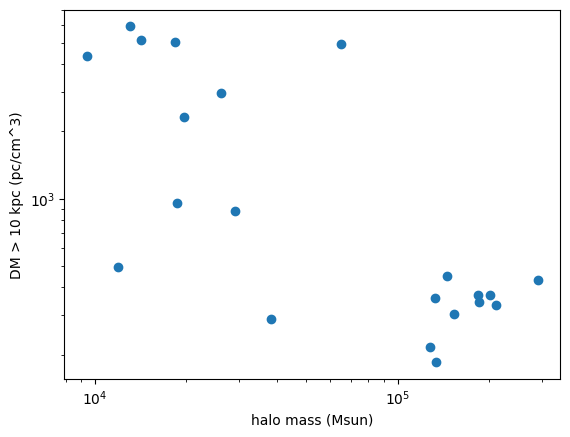

Text(0, 0.5, 'DM > 10 kpc')

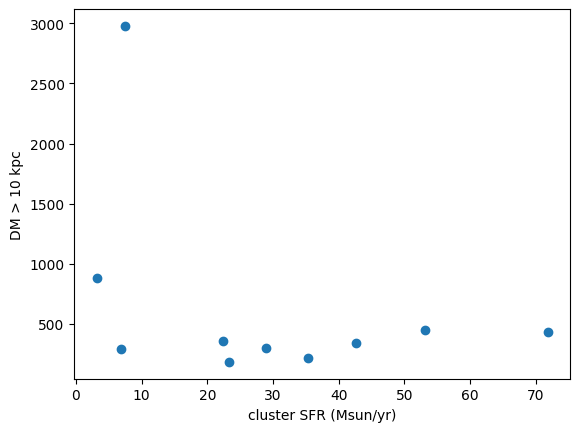

In [31]:
plt.scatter(group_sfr, np.array(dm_far_mean) * (cm_kpc**3) * 1000)
# plt.scatter(group_sfr, (np.array(dm_far_mean) - np.array(dm_far_std)) * (cm_kpc**3) * 1000)
# plt.scatter(group_sfr, (np.array(dm_far_mean) + np.array(dm_far_std)) * (cm_kpc**3) * 1000)
plt.xlabel('cluster SFR (Msun/yr)')
plt.ylabel('DM > 10 kpc')

In [57]:
np.max(star_ssfr)

np.float64(6.8084013982172564e-09)

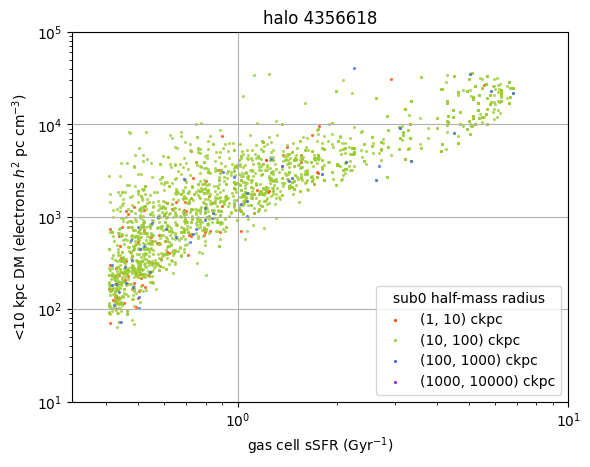

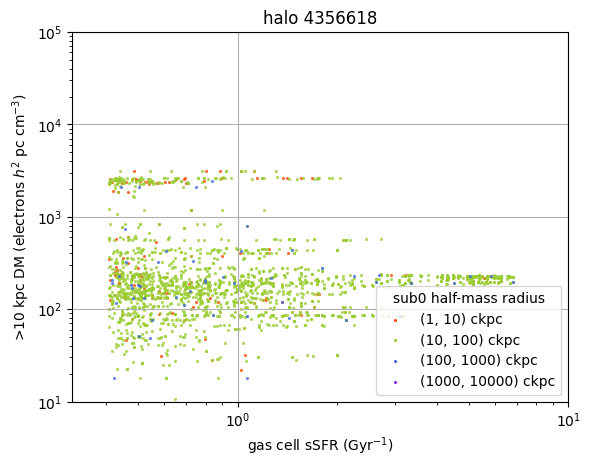

In [58]:
for (j, dm) in enumerate((dm_near, dm_far)):
    plt.title('halo ' + halo_id)
    
    for i in np.arange(1, 5):
        select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
        plt.scatter(
            star_ssfr[select] * 1e9, 
            dm[select] * (cm_kpc**3) * 1000, 
            s=5, alpha=0.8, lw=0, c=colors[i],
            label=f'({10.**(i-1):.0f}, {10**i:.0f}) ckpc'
        )
        # print(sub_lums)
    plt.xlabel('gas cell sSFR (Gyr$^{-1}$)')
    plt.gca().set_xscale('log')
    plt.gca().set_yscale('log')
    plt.ylim(1e1, 1e5)
    plt.xlim(10**-0.5, 10**1)
    plt.ylabel('<>'[j] + '10 kpc DM (electrons $h^2$ pc cm$^{-3}$)')
    leg = plt.legend(title='sub0 half-mass radius', loc='lower right')
    for lh in leg.legend_handles:
        lh.set_alpha(1)
    plt.grid()
    plt.savefig(f'outputs/plots/halo{halo_id}_dmssfr.png')
    plt.show()


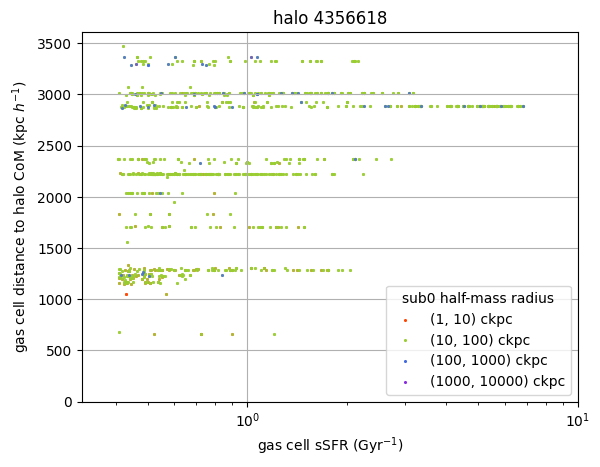

In [59]:
plt.title('halo ' + halo_id)

for i in np.arange(1, 5):
    select = (10**(i-1) < sub_rads) & (sub_rads < 10**i)
    plt.scatter(
        star_ssfr[select] * 1e9, 
        np.sqrt(raytrace.norm2(star_pos[select])), 
        s=5, alpha=0.8, lw=0, c=colors[i],
        label=f'({10.**(i-1):.0f}, {10**i:.0f}) ckpc'
    )
    # print(sub_lums)
plt.xlabel('gas cell sSFR (Gyr$^{-1}$)')
plt.gca().set_xscale('log')
# plt.gca().set_yscale('log')
# plt.ylim(1e1, 1e5)
plt.ylim(0)
plt.xlim(10**-0.5, 10**1)
plt.ylabel('gas cell distance to halo CoM (kpc $h^{-1}$)')
leg = plt.legend(title='sub0 half-mass radius', loc='lower right')
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.grid()
plt.savefig(f'outputs/plots/halo{halo_id}_dmssfr.png')
plt.show()


Text(0.5, 0, 'ssfr (/Gyr)')

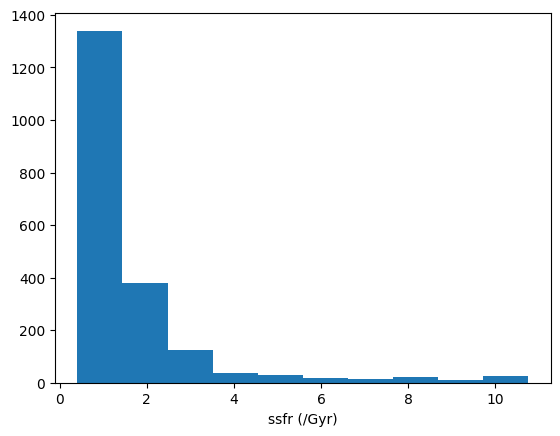

In [166]:
plt.hist(star_ssfr*1e9)
plt.xlabel('ssfr (/Gyr)')

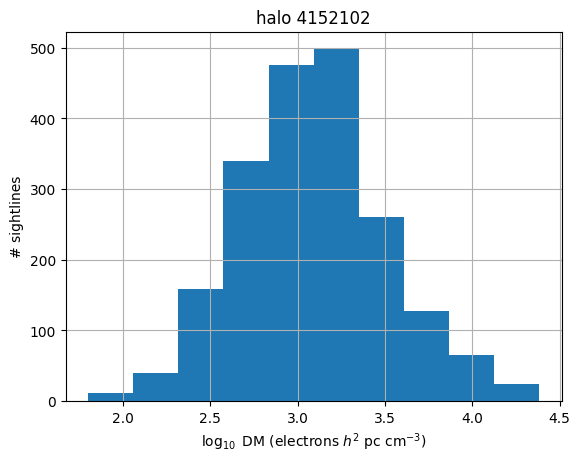

In [93]:
plt.title('halo ' + halo_id)
plt.hist(np.log10(dm * (cm_kpc**3) * 1000))
plt.grid()
plt.xlabel('$\log_{10}$ DM (electrons $h^2$ pc cm$^{-3}$)')
plt.ylabel('# sightlines')
plt.show()